In [1]:
#Dane dotyczące bezrobocia pobrane z eurostatu:
#Do wyboru była wersja SA (seasonally adjusted) oraz NSA (not seasonally adjusted), w naszym projekcie wybraliśmy
#SA żeby uniknąć szumu spowodowanego pracami sezonowymi

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("unemployment_monthly_total_sa.csv")

In [3]:
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,s_adj,Seasonal adjustment,indic,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-01,NaN,4.0,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-02,NaN,3.9,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-03,NaN,3.9,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-04,NaN,4.0,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-05,NaN,4.1,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14756 entries, 0 to 14755
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               14756 non-null  str    
 1   STRUCTURE_ID                            14756 non-null  str    
 2   STRUCTURE_NAME                          14756 non-null  str    
 3   freq                                    14756 non-null  str    
 4   Time frequency                          14756 non-null  str    
 5   unit                                    14756 non-null  str    
 6   Unit of measure                         14756 non-null  str    
 7   s_adj                                   14756 non-null  str    
 8   Seasonal adjustment                     14756 non-null  str    
 9   indic                                   14756 non-null  str    
 10  Indicator                               14756 non-null  str    
 11  

In [5]:
#W pobranych danych znajduje się dużo oznaczeń dotyczących struktury i metadata eurostatu, które będą niepotrzebne przy dalszej pracy na danych 
#Finalnie z tego datasetu będą potrzebne 3 kolumny:
# - geo - kraj/zbiór krajów
# - TIME_PERIOD - miesiąc
# - unemployment - współczynnik bezrobocia
#Seasonal adjustment jak bylo wspominanie wyżej zostalo już zdefiniowane przy pobieraniu
#Zostawiamy jeszcze kolumne Geopolitical entity (reporting) która zawiera pełną nazwe kraju w celu wygody przy rysowaniu wykresow

In [6]:
df = df[["geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]

df = df.rename(columns={
    "TIME_PERIOD": "time",
    "OBS_VALUE": "unemployment",
    "Geopolitical entity (reporting)": "country"
})

df["time"] = pd.to_datetime(df["time"])

df = df.sort_values(["geo", "time"]).reset_index(drop=True)

df["geo"] = df["geo"].astype("category")

print(df.head())

  geo  country       time  unemployment
0  AT  Austria 1995-01-01           4.0
1  AT  Austria 1995-02-01           3.9
2  AT  Austria 1995-03-01           3.9
3  AT  Austria 1995-04-01           4.0
4  AT  Austria 1995-05-01           4.1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14756 entries, 0 to 14755
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   geo           14756 non-null  category      
 1   country       14756 non-null  str           
 2   time          14756 non-null  datetime64[us]
 3   unemployment  14756 non-null  float64       
dtypes: category(1), datetime64[us](1), float64(1), str(1)
memory usage: 360.7 KB


In [8]:
#Sprawdzenie danych pod kątem nulli
df.isna().sum()

geo             0
country         0
time            0
unemployment    0
dtype: int64

In [9]:
#Zakres dat
print(df["time"].min())
print(df["time"].max())

1983-01-01 00:00:00
2026-04-01 00:00:00


In [10]:
#Kraje
countries = sorted(df["country"].unique())
print(countries)

['Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Euro area – 21 countries (from 2026)', 'European Union - 27 countries (from 2020)', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom', 'United States']


In [11]:
#Do usunięcia są jeszcze agregatory typu Euro area, zostawiamy jedynie European Union - 27 countries (from 2020) oraz kraje spoza UE
#Następnie rozdzielamy kraje oraz UE na dwa osobne bloki i UE będzie od teraz traktowany jako wskaźnik ogólnej sytuacji gospodarczej (dodatkowa kolumna)
eu_codes_all = [
    'AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','EL','HU','IE','IT','LV','LT','LU','MT','NL',
    'PL','PT','RO','SK','SI','ES','SE',
    'EU27_2020'
]

df_all = df[df["geo"].isin(eu_codes_all)]

#Tylko kraje
df_countries = df_all[df_all["geo"] != "EU27_2020"]

#Tylko UE
df_eu = df_all[df_all["geo"] == "EU27_2020"]


df_final = df_countries.merge(
    df_eu[["time", "unemployment"]],
    on="time",
    how="left"
)

df_final = df_final.rename(columns={
    "unemployment_x": "unemployment",
    "unemployment_y": "unemployment_eu"
})

In [12]:
df_final.head()

,geo,country,time,unemployment,unemployment_eu
0,AT,Austria,1995-01-01,4.0,NaN
1,AT,Austria,1995-02-01,3.9,NaN
2,AT,Austria,1995-03-01,3.9,NaN
3,AT,Austria,1995-04-01,4.0,NaN
4,AT,Austria,1995-05-01,4.1,NaN


In [13]:
df_final.isna().sum()

geo                   0
country               0
time                  0
unemployment          0
unemployment_eu    2616
dtype: int64

In [14]:
#Pojawia sie jednak problem z zakresem (UE ma dane dopiero od 2000 roku, więc trzeba będzie obciąć dane tak zeby zaczynaly sie od 2000 roku)
print(df_countries["time"].min(), df_countries["time"].max())
print(df_eu["time"].min(), df_eu["time"].max())

1983-01-01 00:00:00 2026-04-01 00:00:00
2000-01-01 00:00:00 2026-04-01 00:00:00


In [15]:
start = df_eu["time"].min()
df_countries_trimmed = df_countries[df_countries["time"] >= start]

df_final = df_countries_trimmed.merge(
    df_eu[["time", "unemployment"]],
    on="time",
    how="left"
)

df_final = df_final.rename(columns={
    "unemployment_x": "unemployment",
    "unemployment_y": "unemployment_eu"
})

In [16]:
df_final.isna().sum()

geo                0
country            0
time               0
unemployment       0
unemployment_eu    0
dtype: int64

In [17]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   geo              8531 non-null   category      
 1   country          8531 non-null   str           
 2   time             8531 non-null   datetime64[us]
 3   unemployment     8531 non-null   float64       
 4   unemployment_eu  8531 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(2), str(1)
memory usage: 276.4 KB


In [18]:
df_final.head()

,geo,country,time,unemployment,unemployment_eu
0,AT,Austria,2000-01-01,4.3,9.7
1,AT,Austria,2000-02-01,4.3,9.7
2,AT,Austria,2000-03-01,4.1,9.7
3,AT,Austria,2000-04-01,3.8,9.6
4,AT,Austria,2000-05-01,3.7,9.6


In [19]:
df_final.tail()

,geo,country,time,unemployment,unemployment_eu
8526,SK,Slovakia,2025-12-01,5.7,6.0
8527,SK,Slovakia,2026-01-01,5.7,6.0
8528,SK,Slovakia,2026-02-01,5.8,6.0
8529,SK,Slovakia,2026-03-01,5.8,6.0
8530,SK,Slovakia,2026-04-01,5.8,6.0


In [20]:
#Kolejną cechę którą uwzględnimy w naszych danych będzie inflacja, dane eurostatu umożliwiają pobrać ją w wersji miesięcznej inflacja rok do roku (%)
#Dodatkowo wybraliśmy całkowitą inflacje (tzn nie rozbijaną na np. jedzenie, energię etc.)
df2 = pd.read_csv("inflation_monthly_total_year_to_year.csv")
df2.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,coicop18,Classification of individual consumption by purpose (COICOP) - 2018,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2016-12,NaN,2.5,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-01,NaN,4.0,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-02,NaN,3.7,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-03,NaN,3.8,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-04,NaN,3.6,NaN,NaN,NaN,NaN,NaN


In [21]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 13964 entries, 0 to 13963
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   STRUCTURE                                                            13964 non-null  str    
 1   STRUCTURE_ID                                                         13964 non-null  str    
 2   STRUCTURE_NAME                                                       13964 non-null  str    
 3   freq                                                                 13964 non-null  str    
 4   Time frequency                                                       13964 non-null  str    
 5   unit                                                                 13964 non-null  str    
 6   Unit of measure                                                      13964 non-null  str    
 7   coicop18       

In [22]:
#Z inflacji będziemy potrzebować kolumny OBS_VALUE czyli wartości inflacji oraz TIME_PERIOD


df_inf = df2[[
    "geo", 
    "Geopolitical entity (reporting)", 
    "TIME_PERIOD", 
    "OBS_VALUE"
]]

df_inf = df_inf.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "time",
    "OBS_VALUE": "inflation"
})

df_inf["time"] = pd.to_datetime(df_inf["time"])

df_inf = df_inf.sort_values(["geo", "time"]).reset_index(drop=True)

df_inf["geo"] = df_inf["geo"].astype("category")

#Uwzglednienie tylko krajów UE bez samej UE jako zbiorczej wartości
df_inf = df_inf[df_inf["geo"].isin(
    [code for code in eu_codes_all if code != "EU27_2020"]
)]

print(df_inf.head())

    geo  country       time  inflation
109  AT  Austria 1997-01-01        1.2
110  AT  Austria 1997-02-01        1.4
111  AT  Austria 1997-03-01        1.2
112  AT  Austria 1997-04-01        1.2
113  AT  Austria 1997-05-01        1.3


In [23]:
df_inf["geo"].unique()

['AT', 'BE', 'BG', 'CY', 'CZ', ..., 'PT', 'RO', 'SE', 'SI', 'SK']
Length: 27
Categories (46, str): ['AL', 'AT', 'BE', 'BG', ..., 'TR', 'UK', 'US', 'XK']

In [24]:
print(df_inf["time"].min(), df_inf["time"].max())

1997-01-01 00:00:00 2026-05-01 00:00:00


In [25]:
#Ograniczenie do takich samych wartości czasowych jak w przypadku bezrobocia
start = df_final["time"].min()
end = df_final["time"].max()

df_inf = df_inf[
    (df_inf["time"] >= start) &
    (df_inf["time"] <= end)
]

In [26]:
df_inf.isna().sum()

geo          0
country      0
time         0
inflation    0
dtype: int64

In [27]:
df_inf.info()

<class 'pandas.DataFrame'>
Index: 8532 entries, 145 to 12934
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   geo        8532 non-null   category      
 1   country    8532 non-null   str           
 2   time       8532 non-null   datetime64[us]
 3   inflation  8532 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(1), str(1)
memory usage: 276.4 KB


In [28]:
#Teraz trzeba zmergować obie tabele bezrobocie i inflacja ale jest różnica 1 wiersza więcej dla inflacji, sprawdzamy roznice

#Kombinacje geo + time dla obu datasetów
set_inf = set(zip(df_inf["geo"], df_inf["time"]))
set_unemp = set(zip(df_final["geo"], df_final["time"]))

#Co jest w inflacji a nie ma w unemployment
diff_inf = set_inf - set_unemp

#Co jest w unemployment a nie ma w inflacji
diff_unemp = set_unemp - set_inf

print("Inflation only:", diff_inf)
print("Unemployment only:", diff_unemp)

#Drop dodatkowego wiersza
df_inf = df_inf[
    df_inf.set_index(["geo", "time"]).index.isin(
        df_final.set_index(["geo", "time"]).index
    )
].reset_index(drop=True)

Inflation only: {('EE', Timestamp('2000-01-01 00:00:00'))}
Unemployment only: set()


In [29]:
set_inf = set(zip(df_inf["geo"], df_inf["time"]))
set_unemp = set(zip(df_final["geo"], df_final["time"]))

#Co jest w inflacji a nie ma w unemployment
diff_inf = set_inf - set_unemp

#Co jest w unemployment a nie ma w inflacji
diff_unemp = set_unemp - set_inf

print("Inflation only:", diff_inf)
print("Unemployment only:", diff_unemp)

Inflation only: set()
Unemployment only: set()


In [30]:
df_inf.info()

<class 'pandas.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   geo        8531 non-null   category      
 1   country    8531 non-null   str           
 2   time       8531 non-null   datetime64[us]
 3   inflation  8531 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(1), str(1)
memory usage: 209.8 KB


In [31]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   geo              8531 non-null   category      
 1   country          8531 non-null   str           
 2   time             8531 non-null   datetime64[us]
 3   unemployment     8531 non-null   float64       
 4   unemployment_eu  8531 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(2), str(1)
memory usage: 276.4 KB


In [32]:
#Mergowanie tabel
df_final = df_final.merge(
    df_inf,
    on=["geo", "time"],
    how="left"
)
df_final.isna().sum()

geo                0
country_x          0
time               0
unemployment       0
unemployment_eu    0
country_y          0
inflation          0
dtype: int64

In [33]:
df_final.head()

,geo,country_x,time,unemployment,unemployment_eu,country_y,inflation
0,AT,Austria,2000-01-01,4.3,9.7,Austria,1.4
1,AT,Austria,2000-02-01,4.3,9.7,Austria,2.0
2,AT,Austria,2000-03-01,4.1,9.7,Austria,1.9
3,AT,Austria,2000-04-01,3.8,9.6,Austria,1.8
4,AT,Austria,2000-05-01,3.7,9.6,Austria,1.5


In [34]:
#Cleanowanie po mergu nadmiarowej kolumny
df_final = df_final.drop(columns=["country_y"])
df_final = df_final.rename(columns={"country_x": "country"})
df_final.head()

,geo,country,time,unemployment,unemployment_eu,inflation
0,AT,Austria,2000-01-01,4.3,9.7,1.4
1,AT,Austria,2000-02-01,4.3,9.7,2.0
2,AT,Austria,2000-03-01,4.1,9.7,1.9
3,AT,Austria,2000-04-01,3.8,9.6,1.8
4,AT,Austria,2000-05-01,3.7,9.6,1.5


In [35]:
#PKB jest kolejną cechą którą uwzględnimy, jest ono podawane kwartalnie więc będzie trzeba to uwzględnić
#Dodatkowo współczynnikiem wybranym będzie Chain linked volumes, percentage change on previous period
#Czyli juz gotowy przeloczony wzrost procentowy zmiany w stosunku do poprzedniego okresu
#Seasonally and calendar adjusted data - wybralismy zeby dane byly od razu z poprawką sezonową i kalendarzową
df3 = pd.read_csv("gdp_total.csv")
df3.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,s_adj,Seasonal adjustment,na_item,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1996-Q2,NaN,-0.6,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1996-Q3,NaN,-0.4,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1996-Q4,NaN,-0.4,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1997-Q1,NaN,-13.0,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1997-Q2,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [36]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 5431 entries, 0 to 5430
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               5431 non-null   str    
 1   STRUCTURE_ID                            5431 non-null   str    
 2   STRUCTURE_NAME                          5431 non-null   str    
 3   freq                                    5431 non-null   str    
 4   Time frequency                          5431 non-null   str    
 5   unit                                    5431 non-null   str    
 6   Unit of measure                         5431 non-null   str    
 7   s_adj                                   5431 non-null   str    
 8   Seasonal adjustment                     5431 non-null   str    
 9   na_item                                 5431 non-null   str    
 10  National accounts indicator (ESA 2010)  5431 non-null   str    
 11  ge

In [37]:
#Czyszczenie

df_gdp = df3[[
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "OBS_VALUE"
]]

df_gdp = df_gdp.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "time",
    "OBS_VALUE": "gdp"
})

#Przekształcenie formatu czasu (bierzemy pod uwagę że dane są kwartalne)
df_gdp["time"] = pd.PeriodIndex(df_gdp["time"], freq="Q").to_timestamp()

df_gdp = df_gdp.sort_values(["geo", "time"]).reset_index(drop=True)

df_gdp["geo"] = df_gdp["geo"].astype("category")

#Uwzglednienie tylko krajów UE bez samej UE jako zbiorczej wartości
df_gdp = df_gdp[df_gdp["geo"].isin(
    [code for code in eu_codes_all if code != "EU27_2020"]
)]

print(df_gdp.head())

    geo  country       time  gdp
119  AT  Austria 1995-04-01  1.3
120  AT  Austria 1995-07-01  0.6
121  AT  Austria 1995-10-01  0.8
122  AT  Austria 1996-01-01  0.0
123  AT  Austria 1996-04-01  0.7


In [38]:
df_gdp.info()

<class 'pandas.DataFrame'>
Index: 3412 entries, 119 to 5124
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   geo      3412 non-null   category      
 1   country  3412 non-null   str           
 2   time     3412 non-null   datetime64[us]
 3   gdp      3412 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(1), str(1)
memory usage: 111.3 KB


In [39]:
df_gdp.isna().sum()

geo        0
country    0
time       0
gdp        0
dtype: int64

In [40]:
print(df_gdp["time"].min(), df_gdp["time"].max())

1980-04-01 00:00:00 2026-01-01 00:00:00


In [41]:
print(df_final["time"].min(), df_final["time"].max())

2000-01-01 00:00:00 2026-04-01 00:00:00


In [42]:
#Pojawi sie teraz problem gdyz dane GDP są tylko na 1 kwartał 2026 wiec max do marca więc trzeba przyciąć df_final

start = df_final["time"].min()
end = df_final["time"].max()

df_gdp = df_gdp[
    (df_gdp["time"] >= start) &
    (df_gdp["time"] <= end)
]

df_final = df_final[df_final["time"] <= "2026-03-01"]

In [43]:
#Merge tabel
df_final = df_final.merge(
    df_gdp[["geo", "time", "gdp"]],
    on=["geo", "time"],
    how="left"
)


In [44]:
df_final.head(15)

,geo,country,time,unemployment,unemployment_eu,inflation,gdp
0,AT,Austria,2000-01-01,4.3,9.7,1.4,0.0
1,AT,Austria,2000-02-01,4.3,9.7,2.0,NaN
2,AT,Austria,2000-03-01,4.1,9.7,1.9,NaN
3,AT,Austria,2000-04-01,3.8,9.6,1.8,1.1
4,AT,Austria,2000-05-01,3.7,9.6,1.5,NaN
5,AT,Austria,2000-06-01,3.6,9.5,2.4,NaN
6,AT,Austria,2000-07-01,3.8,9.5,2.0,1.4
7,AT,Austria,2000-08-01,3.8,9.4,1.9,NaN
8,AT,Austria,2000-09-01,3.9,9.4,2.3,NaN
9,AT,Austria,2000-10-01,3.8,9.3,2.2,0.7


In [45]:
#Wypełnienie brakujacych gdp (ze wzgledu na kwartał 2 miesiące zawsze mają NaN wiec trzeba im przypisac wartość poprzednika)
df_final["gdp"] = df_final.groupby("geo")["gdp"].ffill()
df_final.head(15)

,geo,country,time,unemployment,unemployment_eu,inflation,gdp
0,AT,Austria,2000-01-01,4.3,9.7,1.4,0.0
1,AT,Austria,2000-02-01,4.3,9.7,2.0,0.0
2,AT,Austria,2000-03-01,4.1,9.7,1.9,0.0
3,AT,Austria,2000-04-01,3.8,9.6,1.8,1.1
4,AT,Austria,2000-05-01,3.7,9.6,1.5,1.1
5,AT,Austria,2000-06-01,3.6,9.5,2.4,1.1
6,AT,Austria,2000-07-01,3.8,9.5,2.0,1.4
7,AT,Austria,2000-08-01,3.8,9.4,1.9,1.4
8,AT,Austria,2000-09-01,3.9,9.4,2.3,1.4
9,AT,Austria,2000-10-01,3.8,9.3,2.2,0.7


In [46]:
df_final.isna().sum()

geo                0
country            0
time               0
unemployment       0
unemployment_eu    0
inflation          0
gdp                5
dtype: int64

In [47]:
df_final[df_final["gdp"].isna()]

,geo,country,time,unemployment,unemployment_eu,inflation,gdp
2205,EE,Estonia,2000-02-01,14.9,9.7,2.9,NaN
2206,EE,Estonia,2000-03-01,14.2,9.7,3.1,NaN
5984,MT,Malta,2000-01-01,6.9,9.7,3.4,NaN
5985,MT,Malta,2000-02-01,6.9,9.7,3.3,NaN
5986,MT,Malta,2000-03-01,6.9,9.7,3.4,NaN


In [48]:
df_final = df_final.dropna()
df_final[df_final["gdp"].isna()]

,geo,country,time,unemployment,unemployment_eu,inflation,gdp


In [49]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 8499 entries, 0 to 8503
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   geo              8499 non-null   object        
 1   country          8499 non-null   str           
 2   time             8499 non-null   datetime64[us]
 3   unemployment     8499 non-null   float64       
 4   unemployment_eu  8499 non-null   float64       
 5   inflation        8499 non-null   float64       
 6   gdp              8499 non-null   float64       
dtypes: datetime64[us](1), float64(4), object(1), str(1)
memory usage: 531.2+ KB


In [50]:
#Dodanie lag shiftu (informacji o bezrobociu miesiąć temu i bezrobociu rok temu) oraz lag shiftu do PKB
df_final = df_final.sort_values(["geo", "time"])
df_final["unemployment_last_month"] = df_final.groupby("geo")["unemployment"].shift(1)
df_final["unemployment_last_year"] = df_final.groupby("geo")["unemployment"].shift(12)
df_final["gdp_last_month"] = df_final.groupby("geo")["gdp"].shift(1)
df_final["gdp_last_three_months"] = df_final.groupby("geo")["gdp"].shift(3)
df_final["gdp_last_six_months"] = df_final.groupby("geo")["gdp"].shift(6)
df_final["gdp_last_year"] = df_final.groupby("geo")["gdp"].shift(12)
df_final = df_final.dropna()

In [51]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 8175 entries, 12 to 8503
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   geo                      8175 non-null   object        
 1   country                  8175 non-null   str           
 2   time                     8175 non-null   datetime64[us]
 3   unemployment             8175 non-null   float64       
 4   unemployment_eu          8175 non-null   float64       
 5   inflation                8175 non-null   float64       
 6   gdp                      8175 non-null   float64       
 7   unemployment_last_month  8175 non-null   float64       
 8   unemployment_last_year   8175 non-null   float64       
 9   gdp_last_month           8175 non-null   float64       
 10  gdp_last_three_months    8175 non-null   float64       
 11  gdp_last_six_months      8175 non-null   float64       
 12  gdp_last_year            8175 non-null   float64 

In [52]:
df_final.head()

,geo,country,time,unemployment,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year
12,AT,Austria,2001-01-01,3.6,9.3,2.3,-0.3,3.7,4.3,0.7,0.7,1.4,0.0
13,AT,Austria,2001-02-01,3.6,9.2,1.8,-0.3,3.6,4.3,-0.3,0.7,1.4,0.0
14,AT,Austria,2001-03-01,3.7,9.2,1.9,-0.3,3.6,4.1,-0.3,0.7,1.4,0.0
15,AT,Austria,2001-04-01,3.9,9.3,2.6,-0.3,3.7,3.8,-0.3,-0.3,0.7,1.1
16,AT,Austria,2001-05-01,4.0,9.3,2.9,-0.3,3.9,3.7,-0.3,-0.3,0.7,1.1


In [53]:
#Dodanie cechy handel detaliczny, z wyłączeniem handlu pojazdami samochodowymi i motocyklami ze współczynnikiem 
#procentowy wzrost lub spadek sprzedaży miesiąc do miesiąca
df4 = pd.read_csv("sales.csv")
df4.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_bt,Business trend indicator,nace_r2,Statistical classification of economic activities in the European Community (NACE Rev. 2),s_adj,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-02,NaN,2.5,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-03,NaN,0.3,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-04,NaN,-2.7,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-05,NaN,6.7,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-06,NaN,-0.5,NaN,NaN,NaN,NaN,NaN


In [54]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 11527 entries, 0 to 11526
Data columns (total 23 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   STRUCTURE                                                                                  11527 non-null  str    
 1   STRUCTURE_ID                                                                               11527 non-null  str    
 2   STRUCTURE_NAME                                                                             11527 non-null  str    
 3   freq                                                                                       11527 non-null  str    
 4   Time frequency                                                                             11527 non-null  str    
 5   indic_bt                                                 

In [55]:
#Czyszczenie
df_rs = df4[[
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "OBS_VALUE"
]]

df_rs = df_rs.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "time",
    "OBS_VALUE": "retail_sales"
})

df_rs["time"] = pd.to_datetime(df_rs["time"])


df_rs = df_rs[df_rs["geo"].isin(
    [code for code in eu_codes_all if code != "EU27_2020"]
)]

df_rs.head()

,geo,country,time,retail_sales
254,AT,Austria,2000-02-01,-0.1
255,AT,Austria,2000-03-01,0.1
256,AT,Austria,2000-04-01,1.9
257,AT,Austria,2000-05-01,0.0
258,AT,Austria,2000-06-01,0.0


In [56]:
df_rs.isna().sum()

geo               0
country           0
time              0
retail_sales    577
dtype: int64

In [57]:
print(df_rs["time"].min(), df_rs["time"].max())
print(df_final["time"].min(), df_final["time"].max())

1991-02-01 00:00:00 2026-04-01 00:00:00
2001-01-01 00:00:00 2026-03-01 00:00:00


In [58]:
#Przycięcie zakresu
start = df_final["time"].min()
end = df_final["time"].max()


df_rs = df_rs[
    (df_rs["time"] >= start) &
    (df_rs["time"] <= end)
]

print(df_rs["time"].min(), df_rs["time"].max())

2001-01-01 00:00:00 2026-03-01 00:00:00


In [59]:
df_rs.isna().sum()

geo               0
country           0
time              0
retail_sales    457
dtype: int64

In [60]:
df_rs[df_rs["retail_sales"].isna()].head()

,geo,country,time,retail_sales
5778,IE,Ireland,2005-02-01,NaN
5779,IE,Ireland,2005-03-01,NaN
5780,IE,Ireland,2005-04-01,NaN
5781,IE,Ireland,2005-05-01,NaN
5782,IE,Ireland,2005-06-01,NaN


In [61]:
df_rs[df_rs["retail_sales"].isna()]["geo"].value_counts()

geo
SE    265
IE    192
Name: count, dtype: int64

In [62]:
#Problem występuje jedynie ze szwecją i irlandią dlatego trzeba będzie te kraje zdropować
df_rs.groupby("geo")["retail_sales"].count().sort_values()

geo
SE     38
IE    111
BG    303
AT    303
CZ    303
DE    303
DK    303
BE    303
EE    303
EL    303
FI    303
ES    303
FR    303
HR    303
HU    303
CY    303
IT    303
LT    303
LV    303
LU    303
NL    303
PL    303
PT    303
MT    303
RO    303
SI    303
SK    303
Name: retail_sales, dtype: int64

In [63]:
df_rs.groupby("geo")["time"].min().sort_values()

geo
AT   2001-01-01
SE   2001-01-01
RO   2001-01-01
PT   2001-01-01
PL   2001-01-01
NL   2001-01-01
MT   2001-01-01
LV   2001-01-01
LU   2001-01-01
LT   2001-01-01
IT   2001-01-01
IE   2001-01-01
SI   2001-01-01
HU   2001-01-01
FR   2001-01-01
FI   2001-01-01
ES   2001-01-01
EL   2001-01-01
EE   2001-01-01
DK   2001-01-01
DE   2001-01-01
CZ   2001-01-01
CY   2001-01-01
BG   2001-01-01
BE   2001-01-01
HR   2001-01-01
SK   2001-01-01
Name: time, dtype: datetime64[us]

In [64]:
#Łączenie z główną tabelą
df_final = df_final.merge(
    df_rs[["geo", "time", "retail_sales"]],
    on=["geo", "time"],
    how="left"
)

df_final.head()

,geo,country,time,unemployment,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year,retail_sales
0,AT,Austria,2001-01-01,3.6,9.3,2.3,-0.3,3.7,4.3,0.7,0.7,1.4,0.0,-1.2
1,AT,Austria,2001-02-01,3.6,9.2,1.8,-0.3,3.6,4.3,-0.3,0.7,1.4,0.0,0.5
2,AT,Austria,2001-03-01,3.7,9.2,1.9,-0.3,3.6,4.1,-0.3,0.7,1.4,0.0,0.9
3,AT,Austria,2001-04-01,3.9,9.3,2.6,-0.3,3.7,3.8,-0.3,-0.3,0.7,1.1,-2.2
4,AT,Austria,2001-05-01,4.0,9.3,2.9,-0.3,3.9,3.7,-0.3,-0.3,0.7,1.1,0.0


In [65]:
df_final.isna().sum()

geo                          0
country                      0
time                         0
unemployment                 0
unemployment_eu              0
inflation                    0
gdp                          0
unemployment_last_month      0
unemployment_last_year       0
gdp_last_month               0
gdp_last_three_months        0
gdp_last_six_months          0
gdp_last_year                0
retail_sales               457
dtype: int64

In [66]:
df_final.isna().sum()

geo                          0
country                      0
time                         0
unemployment                 0
unemployment_eu              0
inflation                    0
gdp                          0
unemployment_last_month      0
unemployment_last_year       0
gdp_last_month               0
gdp_last_three_months        0
gdp_last_six_months          0
gdp_last_year                0
retail_sales               457
dtype: int64

In [67]:
df_final[df_final["retail_sales"].isna()]["geo"].value_counts()

geo
SE    265
IE    192
Name: count, dtype: int64

In [68]:
#Dropnięcie Irlandi i Szwecji
df_final = df_final[~df_final["geo"].isin(["SE", "IE"])]

In [69]:
df_final.isna().sum()

geo                        0
country                    0
time                       0
unemployment               0
unemployment_eu            0
inflation                  0
gdp                        0
unemployment_last_month    0
unemployment_last_year     0
gdp_last_month             0
gdp_last_three_months      0
gdp_last_six_months        0
gdp_last_year              0
retail_sales               0
dtype: int64

In [70]:
#Przerzucenie kolumny unemployment na koniec (ze względów czysto estetycznych)
cols = [col for col in df_final.columns if col != "unemployment"] + ["unemployment"]
df_final = df_final[cols]

In [71]:
df_final.corr(numeric_only=True)

,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year,retail_sales,unemployment
unemployment_eu,1.000000,-0.288279,0.024041,0.432627,0.378558,0.002118,-0.038054,-0.062060,-0.104715,-0.000535,0.433906
inflation,-0.288279,1.000000,-0.008800,-0.189081,-0.171296,0.005589,0.040195,0.083518,0.167748,-0.029798,-0.186513
gdp,0.024041,-0.008800,1.000000,-0.010333,0.047382,0.650658,-0.047251,0.047415,0.041064,0.043740,-0.025889
unemployment_last_month,0.432627,-0.189081,-0.010333,1.000000,0.946085,-0.025773,-0.052945,-0.078193,-0.113941,-0.004461,0.997793
unemployment_last_year,0.378558,-0.171296,0.047382,0.946085,1.000000,0.045153,0.038073,0.025814,-0.019903,0.010886,0.938127
gdp_last_month,0.002118,0.005589,0.650658,-0.025773,0.045153,1.000000,0.302091,0.015300,0.060828,-0.051922,-0.039903
gdp_last_three_months,-0.038054,0.040195,-0.047251,-0.052945,0.038073,0.302091,1.000000,-0.048857,0.100314,0.018646,-0.064033
gdp_last_six_months,-0.062060,0.083518,0.047415,-0.078193,0.025814,0.015300,-0.048857,1.000000,0.049923,0.046359,-0.084905
gdp_last_year,-0.104715,0.167748,0.041064,-0.113941,-0.019903,0.060828,0.100314,0.049923,1.000000,-0.014219,-0.118768
retail_sales,-0.000535,-0.029798,0.043740,-0.004461,0.010886,-0.051922,0.018646,0.046359,-0.014219,1.000000,-0.008084


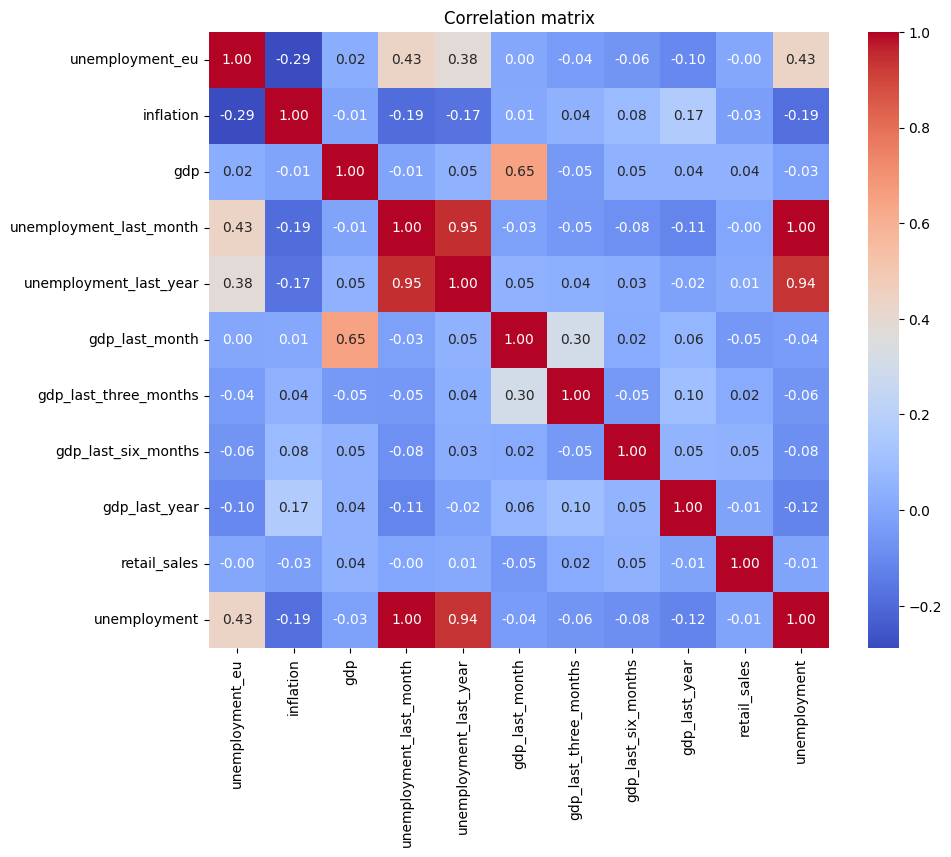

In [72]:
#Macierz korelacji
corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()


In [73]:
#Dropnięcie retail_sales
df_final = df_final.drop(columns=["retail_sales"])

In [74]:
df_final.head()

,geo,country,time,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year,unemployment
0,AT,Austria,2001-01-01,9.3,2.3,-0.3,3.7,4.3,0.7,0.7,1.4,0.0,3.6
1,AT,Austria,2001-02-01,9.2,1.8,-0.3,3.6,4.3,-0.3,0.7,1.4,0.0,3.6
2,AT,Austria,2001-03-01,9.2,1.9,-0.3,3.6,4.1,-0.3,0.7,1.4,0.0,3.7
3,AT,Austria,2001-04-01,9.3,2.6,-0.3,3.7,3.8,-0.3,-0.3,0.7,1.1,3.9
4,AT,Austria,2001-05-01,9.3,2.9,-0.3,3.9,3.7,-0.3,-0.3,0.7,1.1,4.0


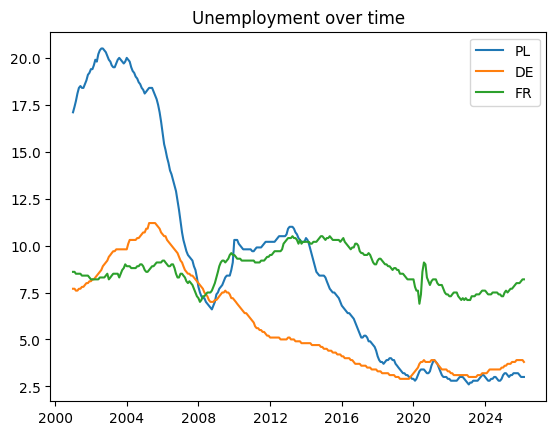

In [75]:
#Trend bezrobocia dla Polski, Niemiec i Francji
countries = ["PL", "DE", "FR"]

for c in countries:
    subset = df_final[df_final["geo"] == c]
    plt.plot(subset["time"], subset["unemployment"], label=c)

plt.legend()
plt.title("Unemployment over time")
plt.show()

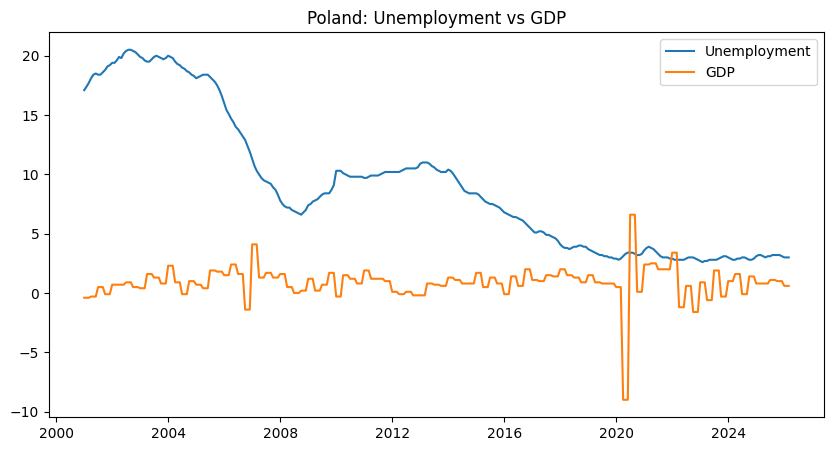

In [76]:
#Porównanie dla polski bezrobocia i PKB
plt.figure(figsize=(10,5))

subset = df_final[df_final["geo"] == "PL"]

plt.plot(subset["time"], subset["unemployment"], label="Unemployment")
plt.plot(subset["time"], subset["gdp"], label="GDP")

plt.legend()
plt.title("Poland: Unemployment vs GDP")
plt.show()

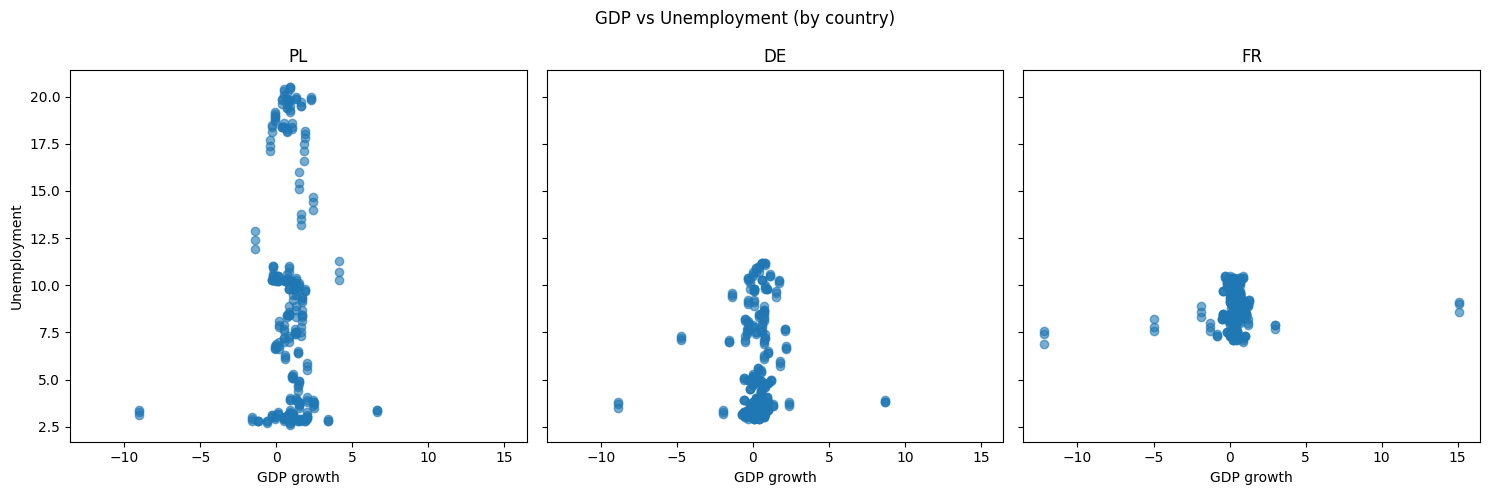

In [77]:
#PKB vs Bezrobocie
countries = ["PL", "DE", "FR"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

for i, c in enumerate(countries):
    data = df_final[df_final["geo"] == c]

    axes[i].scatter(
        data["gdp"],
        data["unemployment"],
        alpha=0.6
    )

    axes[i].set_title(c)
    axes[i].set_xlabel("GDP growth")

axes[0].set_ylabel("Unemployment")

plt.suptitle("GDP vs Unemployment (by country)")
plt.tight_layout()
plt.show()


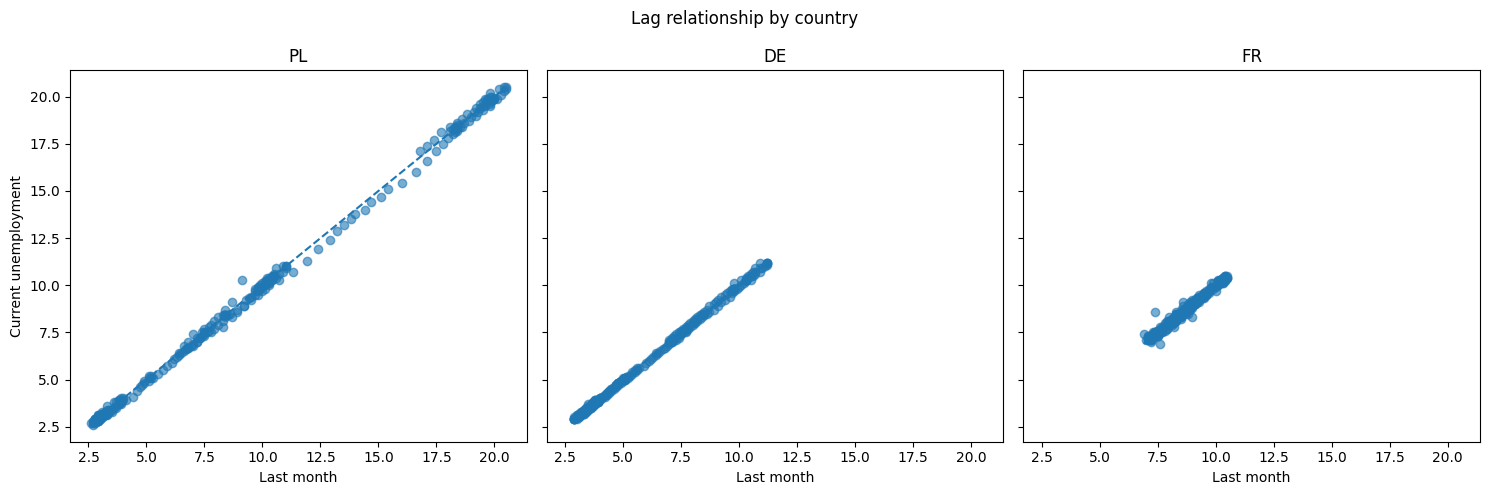

In [78]:
#Wpływ bezrobocia z poprzedniego miesiąca
countries = ["PL", "DE", "FR"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

for i, c in enumerate(countries):
    data = df_final[df_final["geo"] == c]

    axes[i].scatter(
        data["unemployment_last_month"],
        data["unemployment"],
        alpha=0.6
    )

    # linia y=x
    min_val = data["unemployment"].min()
    max_val = data["unemployment"].max()
    axes[i].plot([min_val, max_val], [min_val, max_val], linestyle="--")

    axes[i].set_title(c)
    axes[i].set_xlabel("Last month")

# tylko jeden ylabel żeby było clean
axes[0].set_ylabel("Current unemployment")

plt.suptitle("Lag relationship by country")
plt.tight_layout()
plt.show()

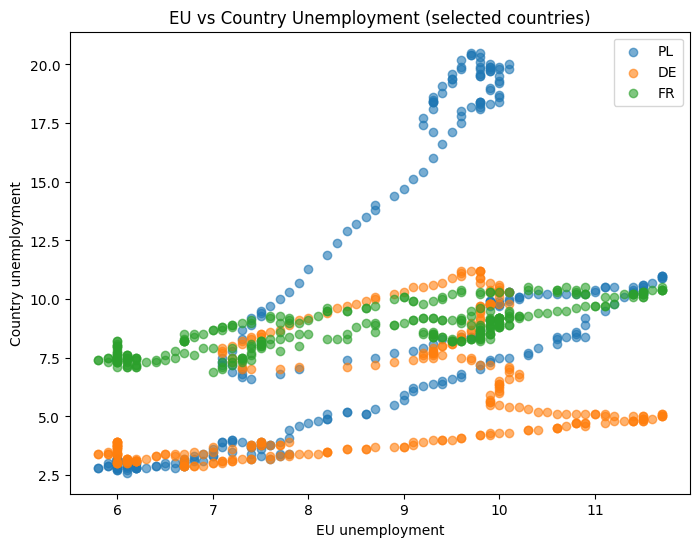

In [79]:
# countries = ["PL", "DE", "FR"]

subset = df_final[df_final["geo"].isin(countries)]

plt.figure(figsize=(8,6))

for c in countries:
    data = subset[subset["geo"] == c]
    plt.scatter(
        data["unemployment_eu"],
        data["unemployment"],
        label=c,
        alpha=0.6
    )

plt.xlabel("EU unemployment")
plt.ylabel("Country unemployment")
plt.legend()
plt.title("EU vs Country Unemployment (selected countries)")
plt.show()

In [80]:
#Sortowanie
df_final = df_final.sort_values(["geo", "time"])

#Split po czasie
train = df_final[df_final["time"] < "2020-01-01"]
test  = df_final[df_final["time"] >= "2020-01-01"]

#Podział na treningowe i testowe (wariant 1)
X_train = train[
    [
        "unemployment_last_month",
        "unemployment_last_year",
        "inflation",
        "gdp_last_year",        #Najlepsze gdp
        "unemployment_eu"
    ]
]

y_train = train["unemployment"]

X_test = test[
    [
        "unemployment_last_month",
        "unemployment_last_year",
        "inflation",
        "gdp_last_year",
        "unemployment_eu"
    ]
]

y_test = test["unemployment"]

In [81]:
#Można by zrobić
#-> Model ze wszystkimi cechami
#-> Model biorący pod uwagę samo bezrobocie w UE
#-> Model biorący pod uwagę inflacje i gdp z zeszlego roku
#I porównać na wykresie

In [82]:
#=========================================================
#OSOBA 2 - PODZIAŁ NA TEST/TRENING + 2 MODELE
#=========================================================

#1. Przygotowanie danych time series - sekwencje [t-3, t-2, t-1] -> t
#Modele drzewiaste (Random Forest, XGBoost) nie operują na surowych sekwencjach 3D tak jak sieci rekurencyjne,
#dlatego "sekwencję" przeszłych obserwacji reprezentujemy w postaci kolumn lagowych (cech opóźnionych),
#które zostały wygenerowane wcześniej w sekcji przygotowania danych:
# - unemployment_last_month -> bezrobocie w t-1
# - unemployment_last_year  -> bezrobocie w t-12
# - gdp_last_month / gdp_last_three_months / gdp_last_six_months / gdp_last_year -> kolejne opóźnienia PKB
#Dzięki temu każdy wiersz to mapowanie [wartości z przeszłości] -> [bezrobocie w czasie t].
#Jawne budowanie tensorów sekwencyjnych zostawiamy modelowi LSTM (Osoba 3).

#2. Podział danych train/test został wykonany powyżej (split po czasie: train < 2020-01-01, test >= 2020-01-01).
#Split czasowy jest właściwy dla szeregów czasowych - nie mieszamy przyszłości z przeszłością podczas walidacji.
#Daje to proporcję zbliżoną do zakładanej 80/20 (train ~ 5694 wierszy, test ~ 1875 wierszy).

In [83]:
#3. Model 1 - Random Forest
#6. Trening modeli - każdy model trenujemy osobno
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,   #liczba drzew w lesie
    max_depth=None,     #drzewa rosną do pełnej głębokości
    random_state=42,    #powtarzalność wyników
    n_jobs=-1           #użycie wszystkich rdzeni procesora
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [84]:
#7. Predykcja Random Forest na zbiorze testowym
pred_rf = rf_model.predict(X_test)
pred_rf[:10]

array([4.541     , 4.544     , 4.497     , 5.04166667, 6.14666667,
       7.162     , 7.97966667, 6.685     , 6.57566667, 6.12666667])

In [85]:
#4. Model 2 - XGBoost
#6. Trening drugiego modelu (osobno)
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=400,       #liczba rund boostingu (drzew)
    learning_rate=0.05,     #tempo uczenia (jak mocno każde drzewo koryguje błąd poprzednich)
    max_depth=5,            #maksymalna głębokość pojedynczego drzewa
    subsample=0.8,          #losowy podzbiór wierszy na drzewo (ogranicza przeuczenie)
    colsample_bytree=0.8,   #losowy podzbiór cech na drzewo
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [86]:
#7. Predykcja XGBoost na zbiorze testowym
pred_xgb = xgb_model.predict(X_test)
pred_xgb[:10]

array([4.4257884, 4.424874 , 4.524765 , 5.002716 , 6.0895596, 7.226107 ,
       7.998762 , 6.598573 , 6.3566628, 6.091159 ], dtype=float32)

In [87]:
#8. Liczenie błędów
#Funkcja licząca podstawowe metryki regresji:
# - MAE  (Mean Absolute Error) - średni błąd bezwzględny (w punktach procentowych bezrobocia)
# - RMSE (Root Mean Squared Error) - pierwiastek z błędu średniokwadratowego (mocniej karze duże błędy)
# - R2   (współczynnik determinacji) - jaką część zmienności danych model wyjaśnia (1.0 = idealnie)
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

metrics_rf = regression_metrics(y_test, pred_rf)
metrics_xgb = regression_metrics(y_test, pred_xgb)

print("Random Forest:", metrics_rf)
print("XGBoost:      ", metrics_xgb)

Random Forest: {'MAE': 0.22578304338624372, 'RMSE': np.float64(0.33558657186609125), 'R2': 0.9837776124540349}
XGBoost:       {'MAE': 0.24346346374511715, 'RMSE': np.float64(0.35657895277138885), 'R2': 0.98168457362555}


In [88]:
#Zestawienie błędów obu modeli w jednej tabeli (do dalszego porównania z modelem LSTM - Osoba 3)
results = pd.DataFrame(
    [metrics_rf, metrics_xgb],
    index=["Random Forest", "XGBoost"]
)
results

,MAE,RMSE,R2
Random Forest,0.225783,0.335587,0.983778
XGBoost,0.243463,0.356579,0.981685


In [89]:
#Dodatkowo: ważność cech w obu modelach (które zmienne najmocniej wpływają na predykcję bezrobocia)
importances = pd.DataFrame({
    "feature": X_train.columns,
    "rf_importance": rf_model.feature_importances_,
    "xgb_importance": xgb_model.feature_importances_
}).sort_values("rf_importance", ascending=False)
importances

,feature,rf_importance,xgb_importance
0,unemployment_last_month,0.996433,0.755177
1,unemployment_last_year,0.001179,0.218673
3,gdp_last_year,0.000799,0.010202
4,unemployment_eu,0.000795,0.013280
2,inflation,0.000793,0.002668
